---
title: Bathymetry visualization
subtitle: Geoprocessing with Python
venue: Pythia Cook-off 2026
---

## Imports

In [18]:
# Import Path to handle the raster path
from pathlib import Path

# Import NumPy for numerical array operations
import numpy as np

# Import Matplotlib for plotting
import matplotlib.pyplot as plt

# Help to create a nice colorbar
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker

# Formatter without scientific notation
formatter = mticker.FuncFormatter(lambda x, pos: f"{int(x):,}")

# Import RasterIO to read the raster data
import rasterio as rio

# Import plotting_extent to display the raster in map coordinates
from rasterio.plot import plotting_extent

## Reading the data with `rasterio`
Rasterio is a dedicated Python library for raster data manipulation

From Rasterio's documentation (available at [https://readthedocs.org/projects/rasterio/downloads/pdf/latest/](https://readthedocs.org/projects/rasterio/downloads/pdf/latest/)):

> "Rasterio’s goal is to be this kind of raster data library – expressing [Geospatial Data Abstraction Library] GDAL’s data model using fewer nonidiomatic extension classes and more idiomatic Python types and protocols, while performing as fast as GDAL’s Python bindings.  
High performance, lower cognitive load, cleaner and more transparent code. This is what Rasterio is about."

We load the `gifford_bathy` raster, compute the hillshade from local gradients, and overlay it with 50% transparency. The bathymetry is displayed using the `jet` colormap (I believe it is the same as the user guide).

In [19]:
# Paths and display parameters
# ============================
bathy_path = '../data/gifford_bathy.tif'

# Raster reading
# ----------------   
with rio.open(bathy_path) as dataset:
    bathy = dataset.read(1, masked=True).astype(float).filled(np.nan)
    transform = dataset.transform
    crs = dataset.crs


# Resolution
dx = abs(transform.a)
dy = abs(transform.e)

print("shape:", bathy.shape)
print("crs:", crs)
print("cell size (resolution):", (dx, dy))
print("depth range:", (np.nanmin(bathy), np.nanmax(bathy)))

shape: (835, 914)
crs: EPSG:32757
cell size (resolution): (50.0, 50.0)
depth range: (np.float64(-3221.864990234375), np.float64(-255.59681701660156))


## Hillshade representation

In [5]:
azimuth_deg = 315.0
altitude_deg = 45.0
z_factor = 3.0
hillshade_alpha = 0.5

surface = bathy * z_factor # Useful to think of when we want to exaggerate some of the contours

# IMPORTANT: The gradient takes into account the resolution of the data, dx, dy, which can be different from 1.
dz_dy, dz_dx = np.gradient(surface, dy, dx)

slope = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
aspect = np.arctan2(dz_dy, -dz_dx)

azimuth = np.deg2rad(360.0 - azimuth_deg + 90.0)
altitude = np.deg2rad(altitude_deg)

shade = (
    np.sin(altitude) * np.cos(slope)
    + np.cos(altitude) * np.sin(slope) * np.cos(azimuth - aspect)
)

hshade = 255.0 * np.clip(shade, 0.0, 1.0)
hshade[np.isnan(bathy)] = np.nan

## Visualization

To visualize the bathymetry, we work between the displayed "pixel" reference vs the actual latitude/longitude coordinate. This is managed by the `transform` part.

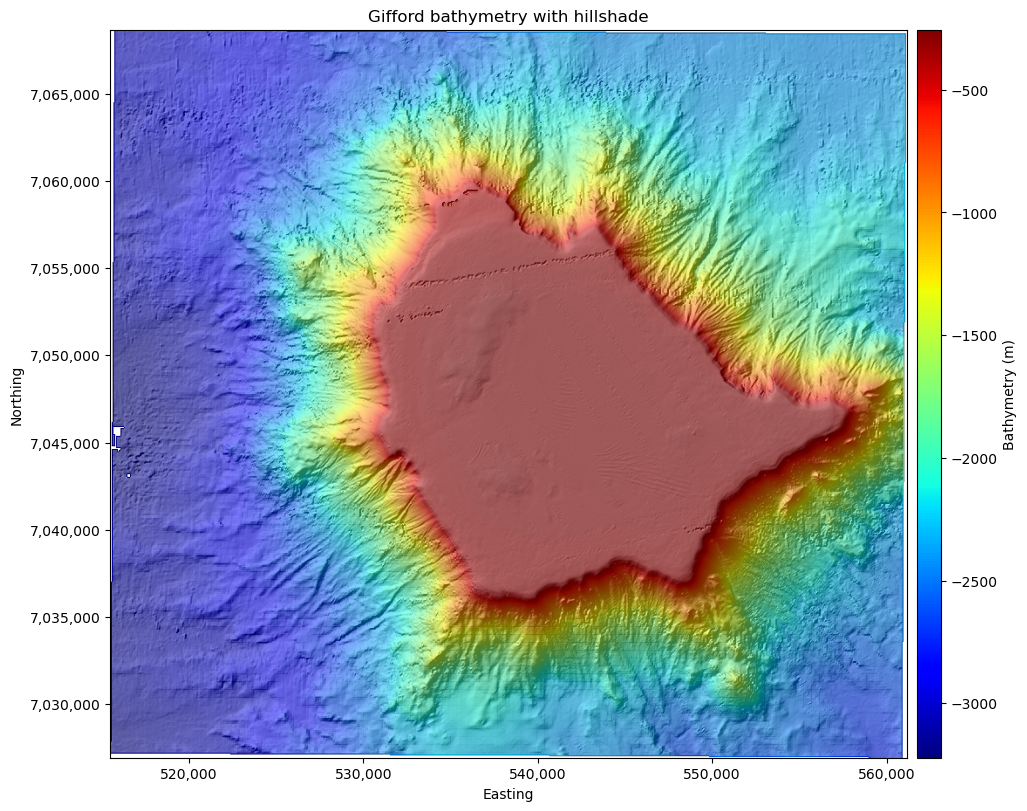

In [6]:
extent = plotting_extent(bathy, transform)

#%% Visualization
# ----------------
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)

im = ax.imshow(bathy,extent=extent,origin="upper",cmap="jet")

ax.imshow(hshade,extent=extent,origin="upper",cmap="gray",alpha=hillshade_alpha)

ax.set_title("Gifford bathymetry with hillshade")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

# Attach colorbar with the same height as the axis
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Bathymetry (m)")

plt.show()

## Creating function for reading and hillsahde

In [7]:
def load_raster(path):
    """
    Load a single-band raster as a floating-point array.

    The first band is read and converted to float. If a nodata value is defined
    in the dataset, it is replaced by NaN to allow safe numerical operations.

    Parameters
    ----------
    path : pathlib.Path or str
        Path to the raster file.

    Returns
    -------
    bathy : numpy.ndarray
        2D array of raster values with NaN for missing data.
    transform : affine.Affine
        Affine transform mapping pixel coordinates to map coordinates.
    crs : rasterio.crs.CRS
        Coordinate reference system of the raster.
    """
    with rio.open(path) as src:
        arr = src.read(1, masked=True).astype(float).filled(np.nan)
        return arr, src.transform, src.crs


def hillshade(
    bathy,
    transform,
    z_factor=1.0,
    azimuth_deg=315.0,
    altitude_deg=45.0,
    invert_bathy=False,
):
    # Pixel sizes. This also works for rotated affine transforms.
    dx = np.hypot(transform.a, transform.d)
    dy = np.hypot(transform.b, transform.e)

    if dx == 0 or dy == 0:
        raise ValueError("Invalid transform: pixel size cannot be zero.")

    surface = bathy.astype(float)

    if invert_bathy:
        surface = -surface

    surface = surface * z_factor

    dz_dy, dz_dx = np.gradient(surface, dy, dx)

    slope = np.arctan(np.hypot(dz_dx, dz_dy))
    aspect = np.arctan2(dz_dy, -dz_dx)

    az = np.deg2rad(360.0 - azimuth_deg + 90.0)
    alt = np.deg2rad(altitude_deg)

    shade = (
        np.sin(alt) * np.cos(slope)
        + np.cos(alt) * np.sin(slope) * np.cos(az - aspect)
    )

    hs = 255.0 * np.clip(shade, 0.0, 1.0)

    hs[np.isnan(bathy)] = np.nan

    return hs

## Using function and visualization

shape: (1972, 1971)
crs: EPSG:32749
cell size (resolution): (50.0, 50.0)
depth range: (np.float64(-65.5770034790039), np.float64(-7.205999851226807))


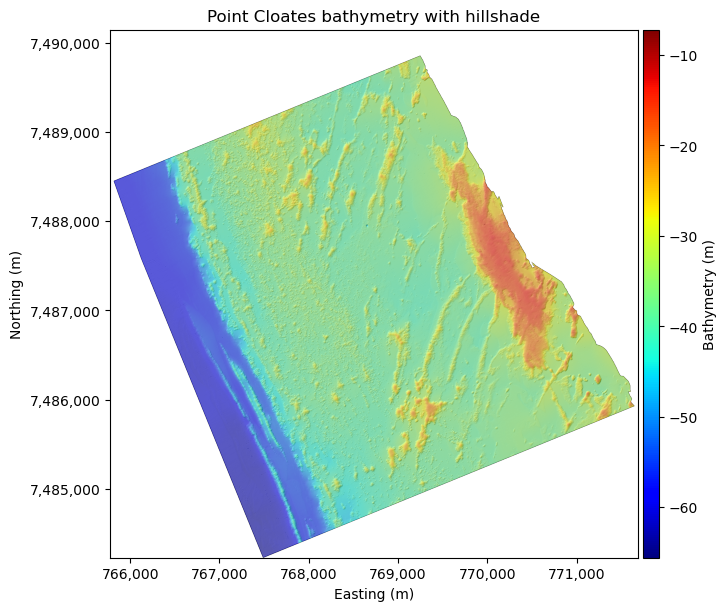

In [8]:
#%% Path
# -------
bathy_path = Path("../data/pc_bathy.tif")

#%% Data Reading
# --------------
bathy, transform, crs = load_raster(bathy_path)
extent = plotting_extent(bathy, transform) # Use for plotting later with imshow

print("shape:", bathy.shape)
print("crs:", crs)
print("cell size (resolution):", (dx, dy))
print("depth range:", (np.nanmin(bathy), np.nanmax(bathy)))

#%% Hillshade
# -----------
hs = hillshade(bathy, transform)

#%% Visualization
# ----------------
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax.imshow(bathy,extent=extent,origin="upper",cmap="jet")
ax.imshow(hs,extent=extent,origin="upper",cmap="gray",alpha=hillshade_alpha)

ax.set_title("Point Cloates bathymetry with hillshade")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Bathymetry (m)")

plt.show()